In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
import os
import warnings
warnings.filterwarnings("ignore", message = ".Glyph.*")
import gc, json, random, shutil, subprocess, sys, time
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image

QUICK = True

BASE = Path.cwd()

ASSETS = BASE / "assets" / "assets"
DATA = BASE / "data" / "data" / "knowledge"
WORK = BASE / "work"
for d in ('models', 'chroma', 'images'):
    (WORK / d).mkdir(parents = True, exist_ok = True)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else: 
    DEVICE = 'cpu'

IMG_DTYPE = torch.float16 if DEVICE in ('cuda', 'mps') else torch.float32

installed = {f.name for f in font_manager.fontManager.ttflist}
for name in ('Malgun Gothic', 'NanumGothic'):
    if name in installed:
        plt.rcParams['font.family'] = name
        break
plt.rcParams['axes.unicode_minus'] = False

In [4]:
def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def free_memory():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

def show_images(images, titles = None, cols = None, size = 3.2):
    cols = cols or len(images)
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize = (size * cols, size * rows), squeeze = False)
    for ax in axes.ravel(): ax.axis('off')
    for i, im in enumerate(images):
        axes.ravel()[i].imshow(im)
        if titles: axes.ravel()[i].set_title(titles[i], fontsize = 10)
    plt.tight_layout(); plt.show()

set_seed(42)
print(DEVICE, QUICK)
print(BASE)

cuda True
c:\Users\KDS23\Documents\17-KDT\17-RAG


In [5]:
from transformers import AutoTokenizer, AutoModel

EMB_NAME = 'intfloat/multilingual-e5-small'
tok = AutoTokenizer.from_pretrained(EMB_NAME)
emb_model = AutoModel.from_pretrained(EMB_NAME).eval().to(DEVICE)

sentences = ['나는 유정이를 사랑합니다.', '오늘만 쉬면 3일 연휴가 2개입니다.']
enc = tok(sentences, padding = True, truncation = True, return_tensors = 'pt')

print(enc['input_ids'])
for i in range(len(sentences)):
    print(tok.convert_ids_to_tokens(enc['input_ids'][i]))
print(enc['attention_mask'])

c:\Users\KDS23\Documents\17-KDT\17-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3360.27it/s]


tensor([[    0, 37231,  5241,  2905,   469,   688, 40434,  8642,     5,     2,
             1,     1,     1,     1,     1,     1],
        [    0, 42742,  3184,     6, 48637,  4253,   138,  1599, 11573, 95174,
           713,   116,  6027,  5826,     5,     2]])
['<s>', '▁나는', '▁유', '정', '이', '를', '▁사랑', '합니다', '.', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<s>', '▁오늘', '만', '▁', '쉬', '면', '▁3', '일', '▁연', '휴', '가', '▁2', '개', '입니다', '.', '</s>']
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [6]:
with torch.no_grad():
    out = emb_model(**enc.to(DEVICE))

emb = out.last_hidden_state

print(tuple(emb.shape))
print(emb[0, 0, :3].cpu().numpy().round(3))

(2, 16, 384)
[ 0.21  -0.082 -0.179]


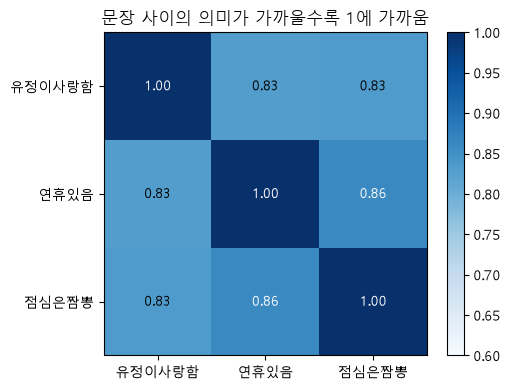

In [7]:
import torch.nn.functional as F


def embed(texts, prefix="query: ", batch_size=32):
    vectors = []

    for i in range(0, len(texts), batch_size):
        batch = [
            prefix + text
            for text in texts[i:i + batch_size]
        ]

        enc = tok(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            hidden = emb_model(**enc).last_hidden_state

        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)

        vectors.append(
            F.normalize(pooled, p=2, dim=1).cpu()
        )

    return torch.cat(vectors, dim=0)


test = [
    "나는 유정이를 사랑합니다.",
    "오늘만 쉬면 3일 연휴가 2개입니다.",
    "오늘의 점심은 짬뽕입니다."
]

vecs = embed(test)
sim = vecs @ vecs.T

labels = [
    "유정이사랑함",
    "연휴있음",
    "점심은짬뽕"
]

fig, ax = plt.subplots(figsize=(5.2, 4))

im = ax.imshow(
    sim.numpy(),
    cmap="Blues",
    vmin=0.6,
    vmax=1.0
)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))

# 문자열 3개가 아니라 리스트 하나를 전달
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = sim[i, j].item()

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value > 0.85 else "black"
        )

ax.set_title("문장 사이의 의미가 가까울수록 1에 가까움")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [8]:
from torchvision import transforms, models

img = Image.open(ASSETS / 'puppy.jpg').convert('RGB')
x = transforms.ToTensor()(img)

weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights = weights).eval()
labels = weights.meta['categories']

batch = weights.transforms()(img).unsqueeze(0)

with torch.no_grad():
    logits = resnet(batch)

probs = torch.softmax(logits, dim = 1)[0]
top_p, top_i = probs.topk(5)

for p, i in zip(top_p, top_i):
    print(f'{labels[i]:25s} {p:6.1%}')

entropy = -(probs * torch.log(probs + 1e-10)).sum()

Labrador retriever         23.9%
Sealyham terrier           18.3%
tennis ball                11.6%
Great Pyrenees             11.6%
golden retriever            7.6%


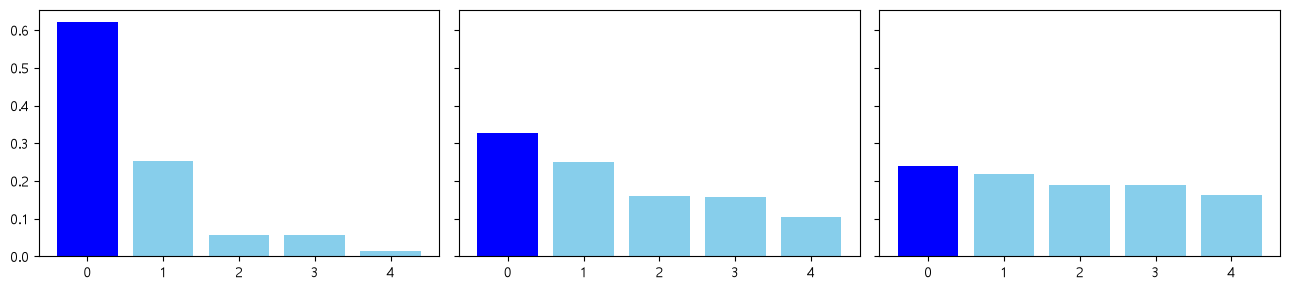

In [9]:
top_logits = logits[0].topk(5).values
fig, axes = plt.subplots(1, 3, figsize = (13,3), sharey = True)

for ax, T in zip(axes, (0.3, 1.0, 3.0)):
    p = torch.softmax(top_logits / T, dim = 0)
    ax.bar(range(5), p.numpy(), color = ['blue'] + ['skyblue'] * 4)
plt.tight_layout(); plt.show()

In [10]:
from huggingface_hub import HfApi, hf_hub_download, ModelCard

api = HfApi()
try:
    info = api.model_info(EMB_NAME)
    print(info.id)
    print(info.pipeline_tag)
    print(info.downloads)
    print(info.tags)
    for m in api.list_models(filter = 'text-classification', sort = 'downloads', limit = 5):
        print(m.id)

except Exception as e:
    print('Failed')

intfloat/multilingual-e5-small
sentence-similarity
11241915
['sentence-transformers', 'pytorch', 'onnx', 'safetensors', 'openvino', 'bert', 'mteb', 'Sentence Transformers', 'sentence-similarity', 'multilingual', 'af', 'am', 'ar', 'as', 'az', 'be', 'bg', 'bn', 'br', 'bs', 'ca', 'cs', 'cy', 'da', 'de', 'el', 'en', 'eo', 'es', 'et', 'eu', 'fa', 'fi', 'fr', 'fy', 'ga', 'gd', 'gl', 'gu', 'ha', 'he', 'hi', 'hr', 'hu', 'hy', 'id', 'is', 'it', 'ja', 'jv', 'ka', 'kk', 'km', 'kn', 'ko', 'ku', 'ky', 'la', 'lo', 'lt', 'lv', 'mg', 'mk', 'ml', 'mn', 'mr', 'ms', 'my', 'ne', 'nl', 'no', 'om', 'or', 'pa', 'pl', 'ps', 'pt', 'ro', 'ru', 'sa', 'sd', 'si', 'sk', 'sl', 'so', 'sq', 'sr', 'su', 'sv', 'sw', 'ta', 'te', 'th', 'tl', 'tr', 'ug', 'uk', 'ur', 'uz', 'vi', 'xh', 'yi', 'zh', 'arxiv:2402.05672', 'arxiv:2108.08787', 'arxiv:2104.08663', 'arxiv:2210.07316', 'license:mit', 'model-index', 'eval-results', 'text-embeddings-inference', 'endpoints_compatible', 'region:us']
cross-encoder/ms-marco-MiniLM-L6-v2
BA

In [11]:
from huggingface_hub import HfApi, hf_hub_download, ModelCard
import json

EMB_NAME = "intfloat/multilingual-e5-small"

try:
    card = ModelCard.load(EMB_NAME)
    print(card.text[:500].strip())
except Exception as e:
    print("Failed")
cfg = json.load(open(hf_hub_download(EMB_NAME, "config.json")))
for k in ("model_type",
          "num_hidden_layers",
          "hidden_size",
          "num_attention_heads",
          "vocab_size",
          "max_position_embeddings"):
    print(cfg[k])

## Multilingual-E5-small

[Multilingual E5 Text Embeddings: A Technical Report](https://arxiv.org/pdf/2402.05672).
Liang Wang, Nan Yang, Xiaolong Huang, Linjun Yang, Rangan Majumder, Furu Wei, arXiv 2024

This model has 12 layers and the embedding size is 384.

## Usage

Below is an example to encode queries and passages from the MS-MARCO passage ranking dataset.

```python
import torch.nn.functional as F

from torch import Tensor
from transformers import AutoTokenizer, AutoModel


def average
bert
12
384
12
250037
512


In [12]:
from transformers import pipeline, set_seed

en_sentiment = pipeline('sentiment-analysis',
model = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english',
device = DEVICE)

for s in ['I love working with transformers!',
          'This was the worst meeting ever']:
    print(s, en_sentiment(s)[0])

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 784.80it/s]


I love working with transformers! {'label': 'POSITIVE', 'score': 0.999541163444519}
This was the worst meeting ever {'label': 'NEGATIVE', 'score': 0.999785840511322}


In [13]:
generator = pipeline('text-generation', model = 'gpt2', device = DEVICE)
prompt = 'The future of AI is'

for temp in (0.3, 1.5):
    set_seed(7)
    out = generator(prompt, max_new_tokens = 30, do_sample = True, temperature = temp, top_k = 50)
    print(temp, out[0]['generated_text'])

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 287.42it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'top_k', 'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_wil

0.3 The future of AI is not yet clear. But it is possible that AI will be able to solve many problems, and that it will be able to solve many problems at once
1.5 The future of AI is not always on-watch; it's changing how technology is perceived today and, at the end of that era it may just break down into smaller and


In [14]:
from transformers import AutoModelForSequenceClassification

name = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english'
tk = AutoTokenizer.from_pretrained(name)
clf = AutoModelForSequenceClassification.from_pretrained(name).eval()

text = 'The club meeting was surprisingly fun!'
enc = tk(text, return_tensors = 'pt')
with torch.no_grad():
    logits = clf(**enc).logits
probs = torch.softmax(logits, dim = -1)[0]

print(tk.convert_ids_to_tokens(enc['input_ids'][0]))
print(logits[0].numpy().round(2))
print(probs.numpy().round(3))
print(clf.config.id2label, clf.config.id2label[int(probs.argmax())])

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2047.44it/s]

['[CLS]', 'the', 'club', 'meeting', 'was', 'surprisingly', 'fun', '!', '[SEP]']
[-4.28  4.61]
[0. 1.]
{0: 'NEGATIVE', 1: 'POSITIVE'} POSITIVE


In [15]:
bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')
print(bert_tok.tokenize('The ultramarathoner prequalified for the immunohistochemistry conference.'))
for s in ['인공지능비서', '머신러닝', '동아리의 해커톤']:
    print(f'다국어 e5: {s!r:14} ->', tok.tokenize(s))

['the', 'ultra', '##mara', '##th', '##one', '##r', 'pre', '##qual', '##ified', 'for', 'the', 'im', '##mun', '##oh', '##isto', '##chemist', '##ry', 'conference', '.']
다국어 e5: '인공지능비서'       -> ['▁인공지능', '비', '서']
다국어 e5: '머신러닝'         -> ['▁머', '신', '러', '닝']
다국어 e5: '동아리의 해커톤'     -> ['▁동', '아리', '의', '▁해', '커', '톤']


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3400.43it/s]
C:\Users\KDS23\AppData\Local\Temp\ipykernel_31072\3136831706.py:17: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\KDS23\Documents\17-KDT\17-RAG\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


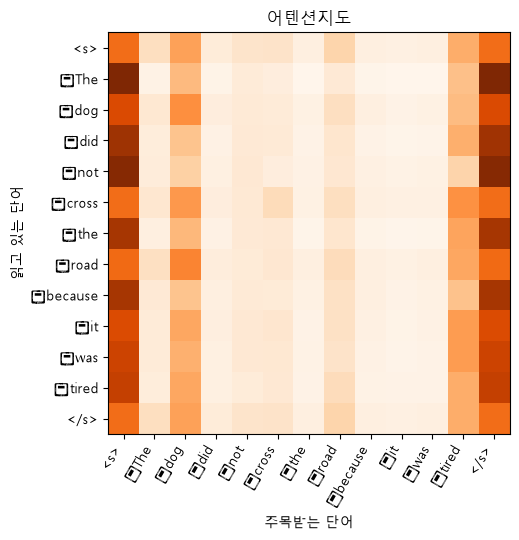

In [16]:
att_model = AutoModel.from_pretrained(EMB_NAME, attn_implementation = 'eager')
sent = 'The dog did not cross the road because it was tired'
enc = tok(sent, return_tensors = 'pt')
with torch.no_grad():
    att = att_model(**enc, output_attentions = True).attentions[-1][0].mean(0)
tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])

fig, ax = plt.subplots(figsize = (6.5, 5.5))
ax.imshow(att.numpy(), cmap = 'Oranges')
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation = 60, ha = 'right')
ax.set_yticks(range(len(tokens)))
ax.set_yticklabels(tokens)
ax.set_xlabel('주목받는 단어')
ax.set_ylabel('읽고 있는 단어')
ax.set_title('어텐션지도')
plt.tight_layout()
plt.show()

del att_model
free_memory()

In [17]:
from datasets import load_dataset

nsmc = load_dataset('e9t/nsmc', revision = 'refs/convert/parquet')
print(nsmc)

N_TRAIN, N_EVAL = (3000, 1000) if QUICK else (30000, 5000)
train_raw = nsmc['train'].filter(lambda r: r['document'] is not None and len(r['document']) > 3).shuffle(seed = 42).select(range(N_TRAIN))
eval_raw = nsmc['test'].filter(lambda r: r['document'] is not None and len(r['document'])> 3).shuffle(seed = 42).select(range(N_EVAL))

print(len(train_raw), len(eval_raw))
for r in train_raw.select(range(5)):
    print(f'[{'긍정' if r['label'] else '부정'}] {r['document']}')

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})
3000 1000
[부정] 별점 주기도 참~~~~아깝다
[부정] 지루하다..
[부정] OOO기영화 볼것하나없는 최악영화
[긍정] 정말 재밌다....! 기억에 남는 작품..윤시윤...하하...대박이구나...!!!!!!!!!!!!!!
[긍정] 언제봐도 즐거운영화~


In [18]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

ID2LABEL = {0: '부정', 1: '긍정'}


def tokenize_batch(batch):
    return tok(batch['document'], truncation = True, max_length = 64)

train_ds = train_raw.map(tokenize_batch, batched = True, remove_columns = ['id', 'document'])
eval_ds = eval_raw.map(tokenize_batch, batched = True, remove_columns = ['id', 'document'])

def accuracy(eval_pred):
    logits, y = eval_pred
    return {'accuracy': float((np.argmax(logits, axis = -1) == y).mean())}

set_seed(42)
ft_model = AutoModelForSequenceClassification.from_pretrained(EMB_NAME, num_labels = 2, id2label = ID2LABEL, label2id = {v: k for k, v in ID2LABEL.items()})
args = TrainingArguments(output_dir = str(WORK / 'ckpt'), 
                         num_train_epochs = 2 if QUICK else 3, 
                         per_device_train_batch_size = 32,
                         per_device_eval_batch_size = 64,
                         learning_rate = 5e-5,
                         weight_decay = 0.01,
                         eval_strategy = 'epoch',
                         save_strategy = 'no',
                         logging_steps = 20,
                         report_to = 'none',
                         seed = 42)

trainer = Trainer(model = ft_model, 
                  args = args, 
                  train_dataset = train_ds, 
                  eval_dataset = eval_ds, 
                  data_collator = DataCollatorWithPadding(tok),
                  compute_metrics = accuracy)

base_acc = trainer.evaluate()['eval_accuracy']
print(f'파인튜닝 전 정확도: {base_acc:.1%}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3230.25it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.693501,0,0.499000


파인튜닝 전 정확도: 49.9%


In [19]:
t0 = time.time()
trainer.train()
print(f'학습 시간 {time.time() - t0:.1f}초')

ft_acc = trainer.evaluate()['eval_accuracy']
print(f'파인튜닝 후 정확도: {ft_acc:.1%}')

Epoch,Training Loss,Validation Loss,Accuracy
1,0.507875,0.504557,0.775000
2,0.440180,0.486630,0.786000


학습 시간 14.4초


Training Loss,Validation Loss,Epoch,Accuracy
0.440180,0.486630,2,0.786000


파인튜닝 후 정확도: 78.6%


In [20]:
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification, set_seed


class PromptTuningClassifier(nn.Module):
    def __init__(self, model_name, num_virtual_tokens=20):
        super().__init__()

        self.backbone = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            id2label=ID2LABEL,
            label2id={v: k for k, v in ID2LABEL.items()},
        )

        self.backbone.requires_grad_(False)

        for p in self.backbone.classifier.parameters():
            p.requires_grad_(True)

        self.n = num_virtual_tokens
        word_emb = self.backbone.get_input_embeddings()

        init_ids = torch.randint(
            0,
            self.backbone.config.vocab_size,
            (num_virtual_tokens,),
            device=word_emb.weight.device,
        )

        self.prompt = nn.Parameter(
            word_emb(init_ids).detach().clone().unsqueeze(0)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        batch_size = input_ids.shape[0]
        word_emb = self.backbone.get_input_embeddings()(input_ids)
        prompt_emb = self.prompt.expand(batch_size, -1, -1)

        input_embeds = torch.cat(
            [prompt_emb, word_emb],
            dim=1,
        )

        prompt_mask = torch.ones(
            batch_size,
            self.n,
            device=attention_mask.device,
            dtype=attention_mask.dtype,
        )

        mask = torch.cat(
            [prompt_mask, attention_mask],
            dim=1,
        )

        return self.backbone(
            inputs_embeds=input_embeds,
            attention_mask=mask,
            labels=labels,
        )


set_seed(42)

pt_model = PromptTuningClassifier(EMB_NAME).to(DEVICE)

n_train = sum(
    p.numel() for p in pt_model.parameters()
    if p.requires_grad
)
n_total = sum(p.numel() for p in pt_model.parameters())

print('전체 파라미터:', n_total)
print('학습 대상:', n_train)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3214.82it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


전체 파라미터: 117662210
학습 대상: 8450


In [21]:
from torch.utils.data import DataLoader

collate = DataCollatorWithPadding(tok)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True, collate_fn = collate)
eval_loader = DataLoader(eval_ds, batch_size = 64, collate_fn = collate)

def evaluate_pt(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for b in eval_loader:
            b = {k: v.to(DEVICE) for k, v in b.items()}
            y = b.pop('labels')
            correct += (model(b['input_ids'], b['attention_mask']).logits.argmax(-1) == y).sum().item()

        return correct / len(eval_ds)

PT_EPOCHS = 4 if QUICK else 8
opt = torch.optim.AdamW([p for p in pt_model.parameters() if p.requires_grad], lr = 2e-2)
pt_losses = []
for epoch in range(PT_EPOCHS):
    pt_model.train()
    total = 0
    for b in train_loader:
        b = {k: v.to(DEVICE) for k, v in b.items()}
        y = b.pop('labels')
        loss = pt_model(b['input_ids'], b['attention_mask'], labels = y).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pt_model.parameters(), 1.0)
        opt.step()
        opt.zero_grad()
        total += loss.item()

    pt_losses.append(total / len(train_loader))
    print(epoch + 1, pt_losses, evaluate_pt(pt_model))

pt_acc = evaluate_pt(pt_model)
print(pt_acc)

1 [0.6606107506346195] 0.719
2 [0.6606107506346195, 0.5159041180889657] 0.693
3 [0.6606107506346195, 0.5159041180889657, 0.513195869136364] 0.761
4 [0.6606107506346195, 0.5159041180889657, 0.513195869136364, 0.49619349203211194] 0.739
0.739


In [22]:
import json
import shutil
import subprocess
import time
import requests

OLLAMA_URL = 'http://localhost:11434'
LLM_MODEL = 'gemma3:4b'
_ollama_proc = None

def ollama_alive():
    try:
        return requests.get(f'{OLLAMA_URL}/api/tags', timeout = 2).ok
    except requests.RequestException:
        return False

def ensure_ollama(model = LLM_MODEL):
    global _ollama_proc
    if not ollama_alive():
        if shutil.which('ollama') is None:
            raise RuntimeError('올라마가 설치되어 있지 않습니다.')
        print('올라마 서버를 켜는 중')
        log = open(WORK / 'ollama_server.log', 'w')
        _ollama_proc = subprocess.Popen(['ollama', 'serve'], stdout = log, stderr = log, start_new_session = True)
        for _ in range(60):
            if ollama_alive():
                break
            time.sleep(0.5)
        else:
            raise RuntimeError('올라마 서버가 꺼져있습니다. log 확인을 해주세요.')
    have = [m['name'] for m in requests.get(f'{OLLAMA_URL}/api/tags').json().get('models', [])]
    if model not in have and f'{model}:latest' not in have:
        print(f'모델 {model} 다운 받는 중')
        last = -1
        with requests.post(f'{OLLAMA_URL}/api/pull', json = {'model': model}, stream = True) as r:
            for line in r.iter_lines():
                if not line:
                    continue
                d = json.loads(line)
                if d.get('total') and d.get('completed'):
                    pct = int(d['completed'] / d['total'] * 100)
                    if pct // 10 != last // 10:
                        print(f'{pct}%', end = " ", flush = True)
                        last = pct
        print('다운로드 완료')
    print(f'서버준비완료 {model}')

ensure_ollama()

서버준비완료 gemma3:4b


In [23]:
def chat(messages, temperature = 0.7, model = LLM_MODEL, fmt = None, max_tokens = None, seed = None):
    options = {'temperature' : temperature}
    if max_tokens:
        options['num_predict'] = max_tokens
    if seed is not None:
        options['seed'] = seed
    payload = {'model' : model, 'messages' : messages, 'stream' : False, 'options' : options, 'keep_alive' : '30m'}
    if fmt:
        payload['format'] = fmt
    r = requests.post(f'{OLLAMA_URL}/api/chat', json = payload, timeout = 600)
    r.raise_for_status()
    return r.json()['message']['content']

print(chat([{'role' : 'user', 'content' :'안녕하세요. 당신은 누구입니까? 한 문장으로 답해주세요.'}]))

저는 Google에서 훈련한 대규모 언어 모델입니다.


In [24]:
MOA_SYSTEM = ("너는 대학 AI 입문 동아리, '모아'의 친절한 AI비서 '모아'야. "
              "항상 한국어로, 존댓말로, 3문장 이내로 짧게 따뜻하게 대답해줘.")

q = '동아리에 처음 왔는데, 너무 떨려요. 어떡하죠?'

print(
    'System 없이 : ',
    chat(
        [{'role': 'user', 'content': q}],
        max_tokens=120
    ).strip()[:200].replace('\n', ' ')
)

print(
    '성격 부여 후 : ',
    chat(
        [
            {'role': 'system', 'content': MOA_SYSTEM},
            {'role': 'user', 'content': q}
        ],
        max_tokens=120
    ).strip()[:200].replace('\n', ' ')
)

System 없이 :  동아리에 처음 오셨다니 정말 떨리시는 마음 충분히 이해가 갑니다! 새로운 환경에 대한 기대감과 설렘, 그리고 약간의 긴장감까지, 모든 감정이 복합적으로 느껴질 수 있죠. 너무 걱정하지 마세요. 많은 사람들이 처음 동아리에 들어왔을 때 비슷한 감정을 느꼈으니까요.  **1. 떨리는 감정, 자연스럽게 받아들이기:**  *   **감정 인정하기:** "떨린다"는
성격 부여 후 :  안녕하세요! 모아입니다. 동아리에 처음 오셨다니, 당연히 떨리실 수 있어요.  모아와 함께 즐겁게 AI를 알아가시면 됩니다.  궁금한 점이 있다면 언제든지 편하게 말씀해주세요!


In [25]:
class MoaChat:
    def __init__(self, system = MOA_SYSTEM, temperature = 0.7):
        self.messages = [{'role' : 'system', 'content' : system}]
        self.temperature = temperature

    def say(self, text):
        self.messages.append({'role' : 'user', 'content' : text})
        answer = chat(self.messages, temperature = self.temperature)
        self.messages.append({'role' : 'assistant', 'content' : answer})
        return answer

bot = MoaChat()
print(bot.say('저는 권상준이고, 파이썬을 처음 배워요.'))
print(bot.say('제 이름이 뭐였죠?'))
print(chat([{'role' : 'system', 'content' : MOA_SYSTEM}, {'role': 'user', 'content' : '제 이름이 뭐였죠?'}]))

안녕하세요, 권상준 님! 파이썬을 처음 배우신다니 정말 멋지네요. 모아는 권상준 님의 파이썬 학습 여정을 응원하며, 궁금한 점이 있다면 언제든지 편하게 질문해주세요. 😊
권상준 님입니다! 혹시 기억이 잘 안 되셨을 텐데, 다시 한번 알려드립니다. 😊
안녕하세요, 질문 주셔서 감사합니다! 질문자님의 성함은 아직 기억하고 있지 못합니다. 혹시 다시 한번 말씀해주시겠어요? 😊


In [26]:
def chat_stream(messages, temperature = 0.7, model = LLM_MODEL):
    payload = {
        'model': model,
        'messages': messages,
        'stream': True,
        'options': {'temperature': temperature}
    }

    with requests.post(
        f'{OLLAMA_URL}/api/chat',
        json = payload,
        stream = True,
        timeout = 600
    ) as r:
        for line in r.iter_lines():
            if line:
                chunk = json.loads(line)
                print(chunk['message']['content'], end = "", flush = True)


chat_stream([
    {'role': 'system', 'content': MOA_SYSTEM},
    {'role': 'user', 'content': '동아리 마스코트 이름을 뭘로 하는 게 좋을까?'}
])

안녕하세요, 여러분! '모아'입니다. 동아리 마스코트 이름은 귀여운 로봇 캐릭터인 '모아'와 어울리는 '모두'라는 단어를 활용하는 건 어떠세요? '모두'는 우리 동아리 회원 모두를 뜻하기도 하고, 함께 모여 성장하는 의미도 담을 수 있을 것 같아요. 😊

In [27]:
review = '해커톤 때 간식은 맛있었는데, 와이파이가 자꾸 끊겨서 프로젝트 제출을 못 할 뻔했어요. 그래도 팀원 덕분에 즐거웠습니다.'

sys_json = '후기를 읽고 JSON으로만 답해. 키: sentiment (긍정/부정/중립), topics (문자열 배열), complaint (불만 한 줄, 없으면 빈 문자열)'

raw = chat(
    [
        {'role': 'system', 'content': sys_json},
        {'role': 'user', 'content': review}
    ],
    temperature = 0,
    fmt = 'json'
)

parsed = json.loads(raw)

print(
    '구조화된 결과: ',
    json.dumps(parsed, ensure_ascii = False, indent = 2)
)

print(
    '파이썬에서 바로 사용: ',
    parsed['sentiment'],
    parsed['topics']
)

구조화된 결과:  {
  "sentiment": "중립",
  "topics": [
    "간식",
    "와이파이",
    "프로젝트",
    "팀원"
  ],
  "complaint": "와이파이 끊김으로 프로젝트 제출 못할 뻔"
}
파이썬에서 바로 사용:  중립 ['간식', '와이파이', '프로젝트', '팀원']


In [28]:
ALL_REVIEWS = ['와이파이가 느려서 실습 중간에 계속 멈췄어요.',
               '회장님이 질문마다 끝까지 설명해줘서 감동받았습니다.',
               '모임 장소가 좁아서 사람이 많은 날은 앉을 자리가 없어요.',
               '마스코트 스티커가 너무 귀여워요! 노트북에 붙였어요.']

numbered = '\n'.join(f'{i + 1}. {r}' for i, r in enumerate(ALL_REVIEWS))

report = chat([
    {'role': 'system',
     'content': '너는 동아리 운영을 돕는 분석가야. 한국어로 답해줘.'},
    {'role': 'user',
     'content': f'아래는 동아리 행사 후기 모음이야.\n잘한 점 3가지와 개선할 점 3가지를 각각 한 줄로 정리해줘.\n\n{numbered}'}
], temperature = 0.3)

print(report)

## 행사 후기 분석 결과

**잘한 점:**

1.  회장님의 꼼꼼한 설명으로 회원들의 이해도를 높였다.
2.  귀여운 마스코트 스티커로 회원들의 만족도를 높였다.
3.  회원들에게 긍정적인 감정적 경험을 제공했다.

**개선할 점:**

1.  동시 사용자 증가에 대비하여 와이파이 속도 개선 필요.
2.  모임 장소의 규모를 확대하거나, 인원수에 따라 장소를 조정하는 방안 고려.
3.  회원들의 불편을 최소화하기 위해 행사 진행 시 네트워크 환경 및 공간 확보에 더욱 신경 써야 함.


In [29]:
docs = {p.name: p.read_text(encoding = 'utf-8') for p in sorted(DATA.glob('*.txt'))}
print(list(docs))

['01_동아리소개.txt', '02_학습과정.txt', '03_장비와공간.txt', '04_행사일정.txt', '05_자주묻는질문.txt']


In [30]:
def split_text(text, chunk_size = 300, overlap = 50):
    chunks = []
    for para in [p.strip() for p in text.split('\n\n') if p.strip()]:
        if len(para) <= chunk_size:
            chunks.append(para)
        else:
            start = 0
            while start < len(para):
                chunks.append(para[start : start + chunk_size])
                start += chunk_size - overlap
    return chunks

records = []
for name, text in docs.items():
    title, _, body = text.partition('\n\n')
    for c in split_text(body):
        records.append({'text': f'[{title.strip()}] {c}', 'source': name})

print(len(records))

for r in records[:3]:
    print(r['source'], r['text'])

18
01_동아리소개.txt [AI 입문 동아리 '모아' 소개] ## 동아리 목적
'모아'는 전공과 상관없이 누구나 AI를 직접 만져 보며 배우는 대학 연합 학습 동아리입니다. 2024년 3월에 문을 열었고, 현재 회원은 42명입니다. 동아리 슬로건은 "모두 함께 AI 만들기"이며, 코딩 경험이 전혀 없어도 가입할 수 있습니다.
01_동아리소개.txt [AI 입문 동아리 '모아' 소개] ## 정기 모임
정기 모임은 매주 수요일 저녁 7시에 공학관 304호에서 열립니다. 모임 시간은 약 2시간이며, 첫 30분은 간식을 먹으며 근황을 나누는 시간입니다. 수요일이 공휴일이면 같은 시간에 목요일로 옮겨서 진행합니다.
01_동아리소개.txt [AI 입문 동아리 '모아' 소개] ## 회비
회비는 한 학기에 15,000원이며 간식비와 서버 이용료로 사용합니다. 학기 첫 모임 후 2주 안에 총무 박서연에게 계좌이체로 내면 됩니다. 형편이 어려운 회원은 회장에게 말하면 회비를 면제받을 수 있습니다.


In [31]:
import chromadb
from chromadb.config import Settings

chroma = chromadb.PersistentClient(path = str(WORK / 'chroma'), settings = Settings(anonymized_telemetry = False))

try:
    chroma.delete_collection('moa_knowledge')
except Exception:
    pass

collection = chroma.create_collection('moa_knowledge', metadata = {'hnsw:space' : 'cosine'})
doc_vecs = embed([r['text'] for r in records], prefix = 'passage: ')
collection.add(
    ids = [f'chunk-{i}' for i in range(len(records))],
    documents = [r['text'] for r in records],
    metadatas = [{'source' : r['source']} for r in records],
    embeddings = doc_vecs.numpy().tolist()
)

print('저장완료', collection.count(), doc_vecs.shape[1])

저장완료 18 384


In [32]:
def search(question, k = 3):
    q_vec = embed([question], prefix = 'query: ')
    res = collection.query(query_embeddings = q_vec.numpy().tolist(), n_results = k)
    return [{'text' : t, 'source' : m['source'], 'similarity' : 1 - d} for t, m, d in zip(res['documents'][0], res['metadatas'][0], res['distances'][0])]

for question in ['동아리 회비는 얼마인가요?', '컴퓨터는 빌려주나요?', '상금이 있는 대회가 있나요?']:
    print(question)
    for hit in search(question, k = 2):
        print('유사도 : ', hit['similarity'])
        print('출처 : ', hit['source'])
        print('답변 : ', hit['text'][:90])

동아리 회비는 얼마인가요?
유사도 :  0.8991055488586426
출처 :  01_동아리소개.txt
답변 :  [AI 입문 동아리 '모아' 소개] ## 회비
회비는 한 학기에 15,000원이며 간식비와 서버 이용료로 사용합니다. 학기 첫 모임 후 2주 안에 총무 박서연에게
유사도 :  0.8500988483428955
출처 :  01_동아리소개.txt
답변 :  [AI 입문 동아리 '모아' 소개] ## 임원진
회장은 김도윤(컴퓨터공학과 3학년), 부회장은 이하은(국어국문학과 2학년), 총무는 박서연(경영학과 3학년)입니다
컴퓨터는 빌려주나요?
유사도 :  0.8348324298858643
출처 :  03_장비와공간.txt
답변 :  [모아 장비와 공간 이용 안내] ## 노트북 대여
동아리에는 대여용 맥북이 5대 있습니다. 한 번에 최대 7일까지 빌릴 수 있고, 연장은 한 번만 가능합니다. 대
유사도 :  0.804939329624176
출처 :  01_동아리소개.txt
답변 :  [AI 입문 동아리 '모아' 소개] ## 회비
회비는 한 학기에 15,000원이며 간식비와 서버 이용료로 사용합니다. 학기 첫 모임 후 2주 안에 총무 박서연에게
상금이 있는 대회가 있나요?
유사도 :  0.818667471408844
출처 :  05_자주묻는질문.txt
답변 :  [모아 자주 묻는 질문] ## 후기 작성
행사가 끝나면 단체 채팅방에 한 줄 후기를 남겨 주세요. 후기는 다음 행사를 준비하는 데 쓰이며, 후기를 남긴 회원 중 
유사도 :  0.8160659670829773
출처 :  04_행사일정.txt
답변 :  [모아 올해 행사 일정] ## 해커톤
올해 해커톤은 11월 15일 토요일에 공학관 대강당에서 열립니다. 참가비는 무료이고, 팀은 3명에서 4명으로 꾸립니다. 1등


In [33]:
RAG_SYSTEM = ("너는 대학 AI 입문 동아리 '모아'의 AI 비서 '모아'야. 반드시 아래 [참고자료]에 있는 내용만 근거로 한국어 존댓말을 간결하게 대답해줘 "
              "자료에 답이 없으면 지어내지말고 '제가 가진 자료에는 없는 내용이에요. 임원진에게 문의해주세요.' 라고 말해.")
def ask_moa(question, k = 3, temperature = 0.1, show_sources = True):
    hits = search(question, k = k)
    context = '\n\n'.join(f'({h['source']}) {h['text']}' for h in hits)
    answer = chat([
        {'role' : 'system', 'content' : RAG_SYSTEM},
        {'role' : 'user', 'content' : f'[참고자료]\n{context}\n\n[질문]\n{question}'}
    ], temperature = temperature)

    if show_sources:
        answer += '\n\n 출처 : ' + ", ".join(sorted({h['source'] for h in hits}))
    return answer

for q in ['회비는 얼마고 누구한테 내요?', '해커톤 1등 상금이 얼마에요?', '노트북은 며칠 빌릴 수 있어요?']:
    print('질문 : ', q)
    print(ask_moa(q))

질문 :  회비는 얼마고 누구한테 내요?
회비는 한 학기에 15,000원이며, 총무 박서연 님에게 계좌이체로 내시면 됩니다. 학기 첫 모임 후 2주 이내에 납부 부탁드립니다.

 출처 : 01_동아리소개.txt, 04_행사일정.txt, 05_자주묻는질문.txt
질문 :  해커톤 1등 상금이 얼마에요?
해커톤 1등 팀에게는 도서상품권 30만원이 지급됩니다.

 출처 : 01_동아리소개.txt, 04_행사일정.txt, 05_자주묻는질문.txt
질문 :  노트북은 며칠 빌릴 수 있어요?
대여용 맥북은 한 번에 최대 7일까지 빌리실 수 있으며, 연장은 한 번만 가능합니다.

 출처 : 03_장비와공간.txt, 05_자주묻는질문.txt


In [34]:
q = '회장님 나이가 몇 살이에요?'
print('질문 : ', q)
print('답변 : ', ask_moa(q))

질문 :  회장님 나이가 몇 살이에요?
답변 :  회장님 김도윤 님은 컴퓨터공학과 3학년이십니다. 정확한 나이는 제가 가진 자료에는 없습니다.

 출처 : 01_동아리소개.txt, 05_자주묻는질문.txt


In [35]:
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline, StableDiffusionInpaintPipeline, DPMSolverMultistepScheduler

SD_ID = 'stable-diffusion-v1-5/stable-diffusion-v1-5'
SD_INPAINT_ID = 'stable-diffusion-v1-5/stable-diffusion-inpainting'

pipe = StableDiffusionPipeline.from_pretrained(
    SD_ID,
    torch_dtype = IMG_DTYPE,
    variant = 'fp16',
    safety_checker = None,
    requires_safety_checker = False
).to(DEVICE)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.set_progress_bar_config(disable = True)

NEGATIVE = 'low quality, blurry, deformed, ugly, text, watermark'

c:\Users\KDS23\Documents\17-KDT\17-RAG\.venv\Lib\site-packages\diffusers\utils\deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  9.40it/s]


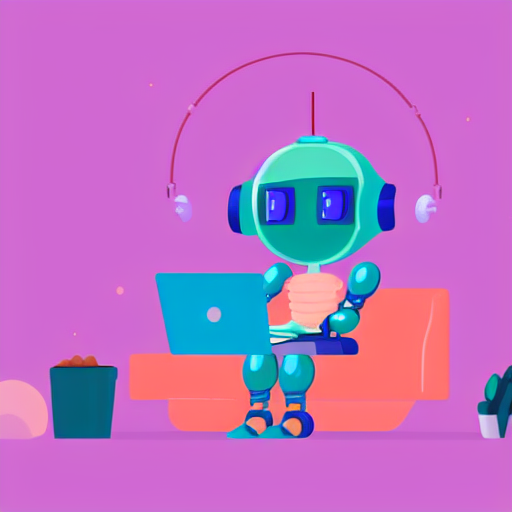

In [36]:
def draw(prompt, negative = NEGATIVE, steps = 20, guidance = 7.5, seed = 0, width = 512, height = 512, pipeline = None, **kw):
    gen = torch.Generator('cpu').manual_seed(seed)
    return (pipeline or pipe)(prompt, negative_prompt = negative, num_inference_steps = steps, guidance_scale = guidance, width = width, height = height, generator = gen, **kw).images[0]

test_img = draw('a cute robot studying with a laptop, flat illustration, pastel colors', seed = 1)
test_img

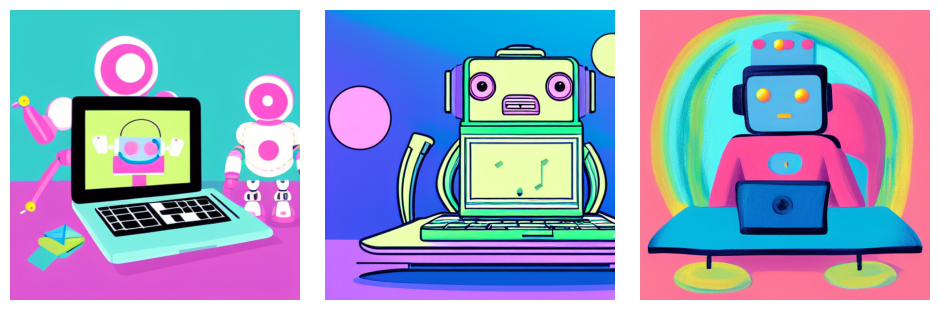

In [37]:
def make_prompt(korean_request):
    return chat([
        {'role': 'system', 'content': "You write prompts for Stable Diffusion, Convert the user's Korean request into ONE English prompt: "
         "comma-separated keywords, vivid style words, max 35 words. Output only the prompt."},
        {'role': 'user', 'content': korean_request}
    ], temperature = 0.4, max_tokens = 100).strip().strip('"')

request = '동아리 홍보에 쓸, 노트북으로 공부하는 귀여운 로봇 일러스트, 파스텔 색감.'
en_prompt = make_prompt(request)
show_images([draw(en_prompt, seed = s) for s in (3, 4, 5)])

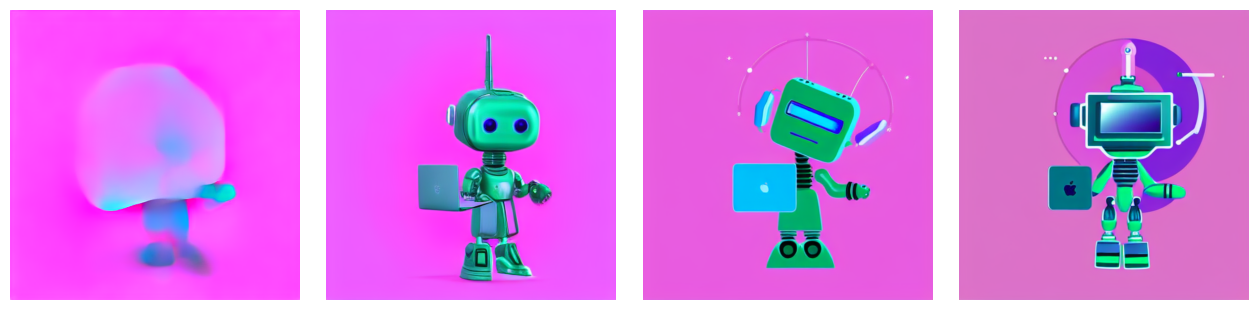

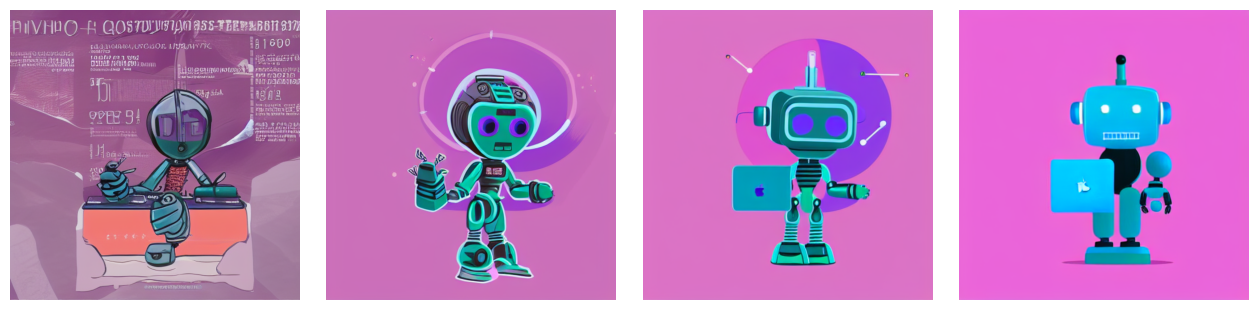

In [38]:
base_prompt = 'a friendly robot mascot holding a laptop, simple flat illustration, pastel colors'

show_images([draw(base_prompt, steps = s, seed = 1) for s in (2, 5, 10, 25)])
show_images([draw(base_prompt, guidance = g, seed = 1) for g in (1, 4, 7.5, 15)])

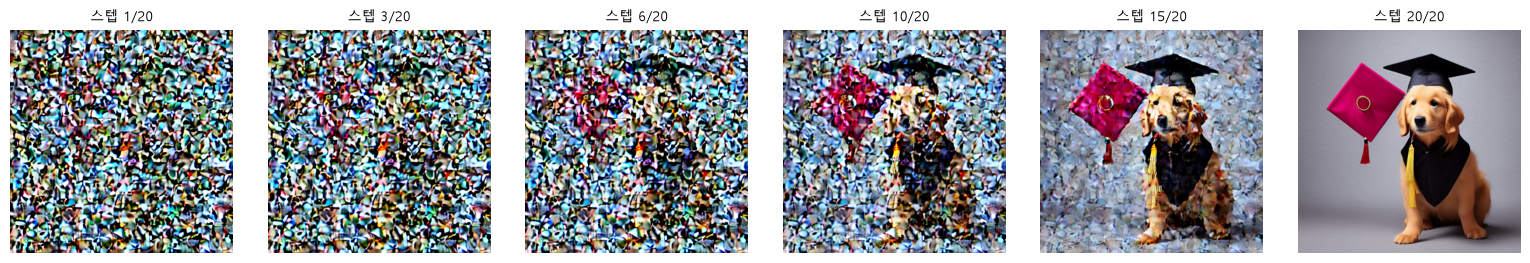

In [39]:
STEPS, SHOW_AT = 20, (0, 2, 5, 9, 14, 19)
snapshots = {}

def capture_step(pipeline, step_index, timestep, callback_kwargs):
    if step_index in SHOW_AT:
        latents = callback_kwargs["latents"]
        with torch.no_grad():
            im = pipeline.vae.decode(latents.to(pipeline.vae.dtype) / pipeline.vae.config.scaling_factor, return_dict=False)[0]
        snapshots[step_index] = pipeline.image_processor.postprocess(im, output_type="pil")[0]
    return callback_kwargs

final = draw("a golden retriever puppy wearing a graduation cap, studio photo", steps=STEPS, seed=21,
             callback_on_step_end=capture_step, callback_on_step_end_tensor_inputs=["latents"])
show_images([snapshots[i] for i in SHOW_AT], [f"스텝 {i + 1}/{STEPS}" for i in SHOW_AT], size=2.6)

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


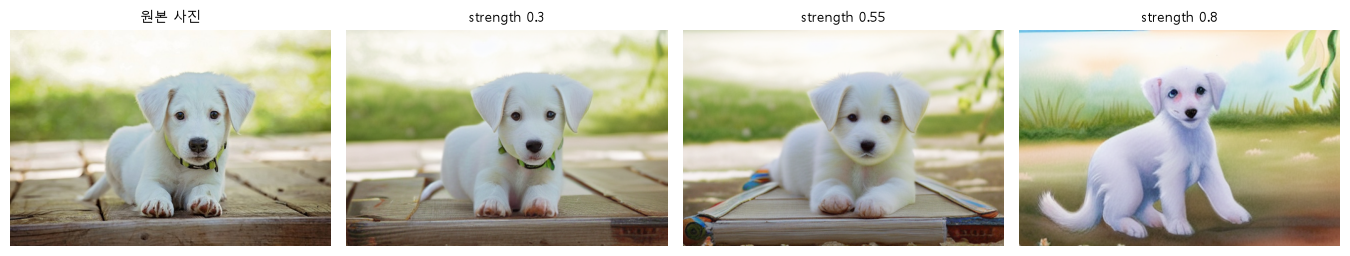

In [40]:
img2img = StableDiffusionImg2ImgPipeline(**pipe.components)          # 이미 올려둔 부품 재사용 → 메모리 절약
img2img.set_progress_bar_config(disable=True)
puppy = Image.open(ASSETS / "puppy.jpg").convert("RGB").resize((512, 344))

watercolor = "a watercolor painting of a white puppy, soft pastel colors, children's book illustration"
outs = [img2img(watercolor, negative_prompt=NEGATIVE, image=puppy, 
                strength=s, guidance_scale=7.5, num_inference_steps=30,
                generator=torch.Generator("cpu").manual_seed(5)).images[0] for s in (0.3, 0.55, 0.8)]
show_images([puppy] + outs, ["원본 사진", "strength 0.3", "strength 0.55", "strength 0.8"], size=3.4)

c:\Users\KDS23\Documents\17-KDT\17-RAG\.venv\Lib\site-packages\diffusers\utils\deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
c:\Users\KDS23\Documents\17-KDT\17-RAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KDS23\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or

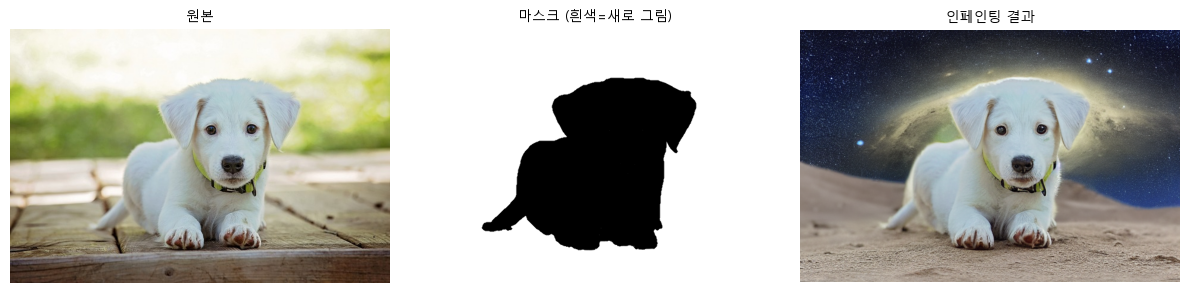

In [41]:
del img2img; free_memory()
inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    SD_INPAINT_ID, torch_dtype=IMG_DTYPE, variant="fp16", safety_checker=None, requires_safety_checker=False).to(DEVICE)
inpaint.set_progress_bar_config(disable=True)

orig = Image.open(ASSETS / "puppy.jpg").convert("RGB")
mask = Image.open(ASSETS / "puppymask.png").convert("L")
W, H = (orig.width // 8 * 8, orig.height // 8 * 8)                   # 그림 모델은 8의 배수 크기를 좋아합니다
moon = inpaint("a white puppy on the surface of the moon, gray lunar craters and dust, black starry sky with earth, photo",
               negative_prompt="grass, wood, trees, " + NEGATIVE, image=orig, mask_image=mask, width=W, height=H,
               num_inference_steps=30, guidance_scale=9, generator=torch.Generator("cpu").manual_seed(42)).images[0]
show_images([orig, mask.convert("RGB"), moon], ["원본", "마스크 (흰색=새로 그림)", "인페인팅 결과"], size=4)

del inpaint; free_memory()

🧠 모아가 쓴 프롬프트: Nighttime hackerathon poster, friends with laptops under a starry sky, futuristic vibe, vibrant colors, detailed, cinematic lighting.


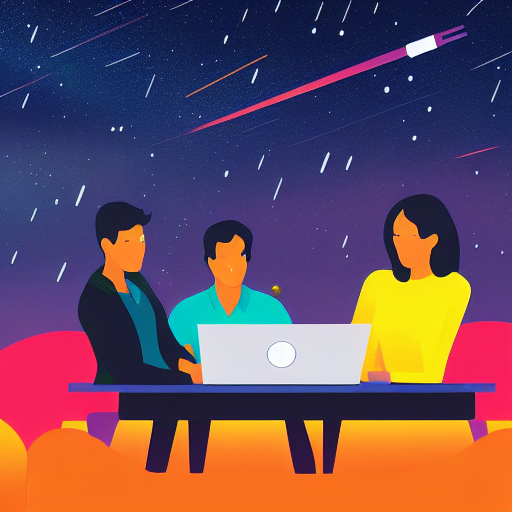

In [42]:
def moa_poster(korean_request, seed=7):
    prompt = make_prompt(korean_request)
    print("🧠 모아가 쓴 프롬프트:", prompt)
    return draw(prompt, seed=seed)

poster = moa_poster("11월 해커톤을 알리는 포스터. 밤하늘 아래 노트북을 든 친구들, 미래적인 분위기")
poster.save(WORK / "images" / "poster_hackathon.png")
poster

In [43]:
d, r = 768, 8                                    # d: 원래 표의 한 변 / r: LoRA의 '랭크'(포스트잇 두께)
W = torch.randn(d, d)                            # 원래 가중치 (고정)
A = torch.randn(d, r) * 0.01                     # 보조 표 1
B = torch.zeros(r, d)                            # 보조 표 2 (처음엔 0 → 시작할 땐 원래 모델과 똑같이 동작!)
x = torch.randn(1, d)

y_original = x @ W
y_lora = x @ W + x @ A @ B
print("처음엔 LoRA가 결과를 바꾸지 않음 →", torch.allclose(y_original, y_lora))
print(f"\n원래 표 W        : {W.numel():>9,}개 숫자")
print(f"LoRA (A + B)     : {A.numel() + B.numel():>9,}개 숫자  → 원래의 {(A.numel() + B.numel()) / W.numel():.1%} 만 학습")

처음엔 LoRA가 결과를 바꾸지 않음 → True

원래 표 W        :   589,824개 숫자
LoRA (A + B)     :    12,288개 숫자  → 원래의 2.1% 만 학습


📸 학습 사진 21장


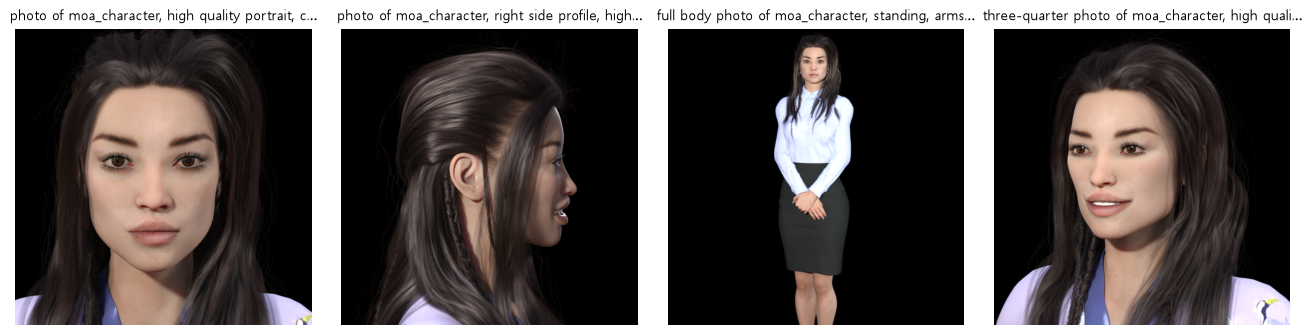

In [44]:
MASCOT_DIR = ASSETS / "mascot"
TRIGGER = "moa_character"                                    # 마스코트를 부르는 '주문' (평소엔 안 쓰는 낯선 단어여야 함)

captions = {}
for line in open(MASCOT_DIR / "metadata.jsonl", encoding="utf-8"):
    row = json.loads(line)
    captions.setdefault(row["file_name"], row["prompt"].replace("(lora-misato-token)", TRIGGER).strip())   # 같은 파일 중복 줄은 첫 번째만
train_files = [f for f in captions if (MASCOT_DIR / f).exists()]
print(f"📸 학습 사진 {len(train_files)}장")

pick = ["front-portrait1.png", "rightprofile-smile.png", "front-full3.png", "34-5-smile.png"]
show_images([Image.open(MASCOT_DIR / f) for f in pick], [captions[f][:48] + "…" for f in pick], size=3.3)

In [47]:
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from diffusers.utils import convert_state_dict_to_diffusers
from torchvision import transforms as T

LORA_DIR = WORK / "models" / "moa-mascot-lora"
RETRAIN = False                                   # True면 저장된 LoRA가 있어도 처음부터 다시 학습
LORA_STEPS = 300 if QUICK else 1200               # 학습 횟수
BATCH, RANK, LR = 2, 8, 1e-4                      # 한 번에 볼 사진 수 / 포스트잇 두께 / 학습률

need_train = RETRAIN or not (LORA_DIR / "pytorch_lora_weights.safetensors").exists()
print("🔁 LoRA 학습이 필요합니다" if need_train else f"✅ 이미 학습된 LoRA가 있어서 학습을 건너뜁니다: {LORA_DIR}")

✅ 이미 학습된 LoRA가 있어서 학습을 건너뜁니다: c:\Users\KDS23\Documents\17-KDT\17-RAG\work\models\moa-mascot-lora


In [48]:
if need_train:
    pipe = None; free_memory()                                        # 파트 6의 그림 모델은 비우고 공간 확보
    set_seed(0)

    tokenizer_sd = CLIPTokenizer.from_pretrained(SD_ID, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(SD_ID, subfolder="text_encoder", variant="fp16", torch_dtype=torch.float32).to(DEVICE).eval()
    vae          = AutoencoderKL.from_pretrained(SD_ID, subfolder="vae", variant="fp16", torch_dtype=torch.float32).to(DEVICE).eval()
    unet         = UNet2DConditionModel.from_pretrained(SD_ID, subfolder="unet", variant="fp16", torch_dtype=torch.float32).to(DEVICE)
    noise_sched  = DDPMScheduler.from_pretrained(SD_ID, subfolder="scheduler")

    # ❄️ 원래 모델은 전부 얼리고, 어텐션 층(to_q, to_k, to_v, to_out)에만 LoRA 포스트잇을 붙인다
    text_encoder.requires_grad_(False); vae.requires_grad_(False); unet.requires_grad_(False)
    unet.add_adapter(LoraConfig(r=RANK, lora_alpha=RANK, init_lora_weights="gaussian",
                                target_modules=["to_k", "to_q", "to_v", "to_out.0"]))
    lora_params = [p for p in unet.parameters() if p.requires_grad]
    n_lora, n_unet = sum(p.numel() for p in lora_params), sum(p.numel() for p in unet.parameters())
    print(f"🔥 학습할 숫자: {n_lora:,}개  /  모델 전체: {n_unet:,}개  ({n_lora / n_unet:.2%})")

    # 📦 사진은 미리 '압축된 형태(latent)'로, 캡션은 미리 '숫자(임베딩)'로 바꿔 두기 (학습 중 매번 계산하지 않도록)
    to_tensor = T.Compose([T.Resize(512), T.CenterCrop(512), T.ToTensor(), T.Normalize([0.5], [0.5])])
    with torch.no_grad():
        latents = torch.cat([
            vae.encode(to_tensor(Image.open(MASCOT_DIR / f).convert("RGB")).unsqueeze(0).to(DEVICE)).latent_dist.sample() * vae.config.scaling_factor
            for f in train_files])
        ids = tokenizer_sd([captions[f] for f in train_files], padding="max_length", truncation=True,
                           max_length=tokenizer_sd.model_max_length, return_tensors="pt").input_ids.to(DEVICE)
        text_embeds = text_encoder(ids)[0]
    print("압축된 사진 shape:", tuple(latents.shape), "| 캡션 임베딩 shape:", tuple(text_embeds.shape))
    del text_encoder, vae; free_memory()

    optimizer = torch.optim.AdamW(lora_params, lr=LR)
    losses, t0 = [], time.time()
    for step in range(1, LORA_STEPS + 1):
        idx = torch.randint(0, len(train_files), (BATCH,))
        x0 = latents[idx]                                                           # 깨끗한 사진(압축본)
        noise = torch.randn_like(x0)                                                # 섞을 잡음
        t = torch.randint(0, noise_sched.config.num_train_timesteps, (BATCH,), device=DEVICE)   # 잡음 세기(0~999) 무작위
        x_noisy = noise_sched.add_noise(x0, noise, t)                               # 1. 잡음 섞기
        pred = unet(x_noisy, t, encoder_hidden_states=text_embeds[idx]).sample      # 2. "섞인 잡음이 뭐게?"
        loss = torch.nn.functional.mse_loss(pred.float(), noise.float())            # 3. 정답과의 차이
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lora_params, 1.0)
        optimizer.step(); optimizer.zero_grad()
        losses.append(loss.item())
        if step % 50 == 0 or step == 1:
            print(f"step {step:>4}/{LORA_STEPS} | loss {np.mean(losses[-50:]):.4f} | 경과 {time.time() - t0:.0f}초")

    # 💾 포스트잇(LoRA)만 저장 — 수 MB
    LORA_DIR.mkdir(parents=True, exist_ok=True)
    StableDiffusionPipeline.save_lora_weights(
        str(LORA_DIR), unet_lora_layers=convert_state_dict_to_diffusers(get_peft_model_state_dict(unet)), safe_serialization=True)
    size_mb = (LORA_DIR / "pytorch_lora_weights.safetensors").stat().st_size / 1e6
    print(f"\n🎓 학습 완료! ({time.time() - t0:.0f}초)  저장된 LoRA 파일 크기: {size_mb:.1f} MB")

    plt.figure(figsize=(6, 3)); k = 20
    plt.plot(np.convolve(losses, np.ones(k) / k, mode="valid"), color="#7c3aed")
    plt.xlabel("학습 단계"); plt.ylabel("loss (이동평균)"); plt.title("LoRA 학습 곡선"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
    del unet, optimizer, latents, text_embeds; free_memory()
else:
    print("⏭️ 학습 생략 (저장된 LoRA 사용)")

⏭️ 학습 생략 (저장된 LoRA 사용)


Loading pipeline components...: 100%|██████████| 6/6 [00:11<00:00,  1.87s/it]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


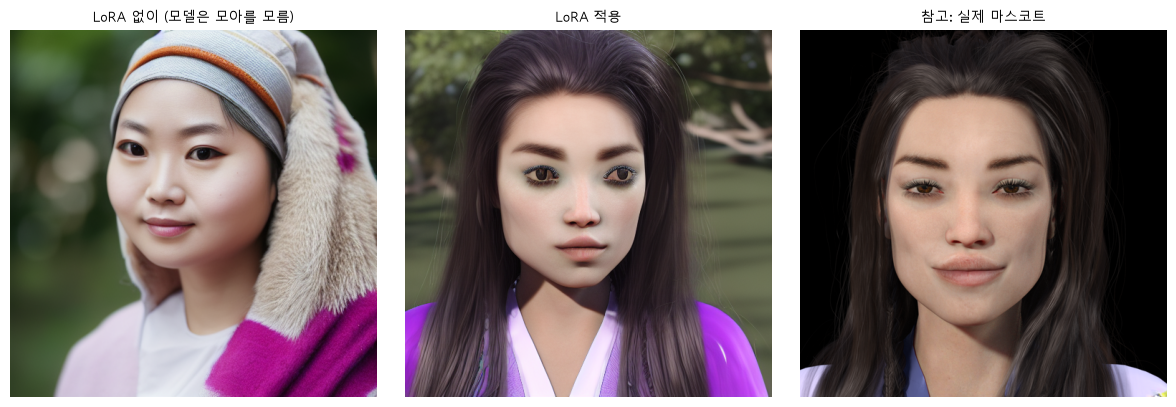

In [49]:
pipe = StableDiffusionPipeline.from_pretrained(
    SD_ID, torch_dtype=IMG_DTYPE, variant="fp16", safety_checker=None, requires_safety_checker=False).to(DEVICE)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.set_progress_bar_config(disable=True)
pipe.load_lora_weights(str(LORA_DIR), adapter_name="moa")                 # 🔌 포스트잇 꽂기

def draw_lora(prompt, use_lora=True, scale=1.0, **kw):
    if use_lora:
        pipe.enable_lora(); pipe.set_adapters(["moa"], adapter_weights=[scale])
    else:
        pipe.disable_lora()
    return draw(prompt, **kw)

prompt = f"a portrait photo of {TRIGGER}, high quality, natural light"
before = draw_lora(prompt, use_lora=False, seed=3)
after  = draw_lora(prompt, use_lora=True, seed=3)
show_images([before, after, Image.open(MASCOT_DIR / "front-portrait3.png")], ["LoRA 없이 (모델은 모아를 모름)", "LoRA 적용", "참고: 실제 마스코트"], size=4)

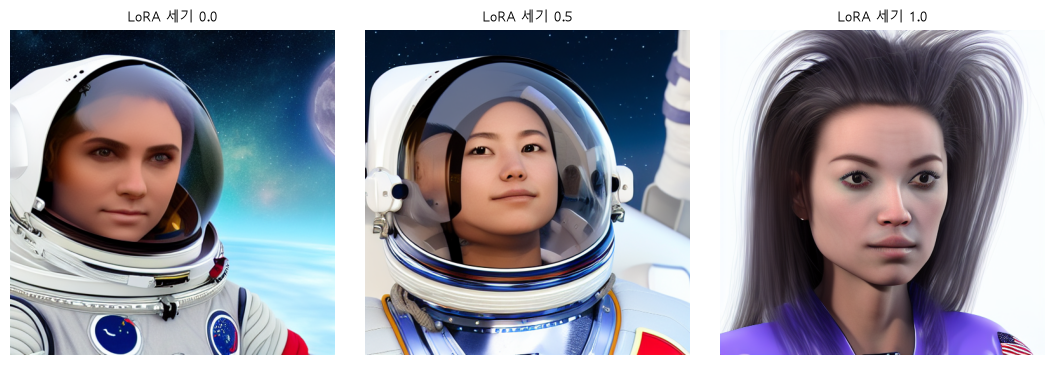

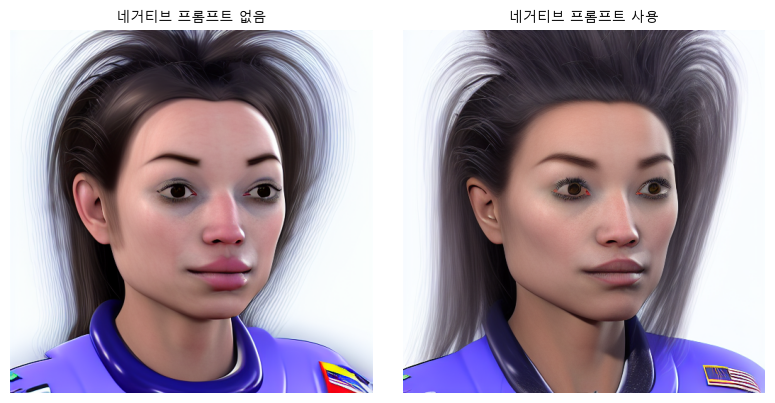

In [50]:
scene = f"portrait of {TRIGGER} as an astronaut, wearing a space suit, face visible, no helmet, moon background"
strengths = (0.0, 0.5, 1.0)
imgs = [draw_lora(scene, use_lora=s > 0, scale=max(s, 0.01), seed=8) for s in strengths]
show_images(imgs, [f"LoRA 세기 {s}" for s in strengths], size=3.6)

bad = "low quality, grainy, blurry, deformed, disfigured, bad anatomy, extra limbs, mutated hands, watermark, text"
show_images([draw_lora(scene, seed=8, negative=""), draw_lora(scene, seed=8, negative=bad)],
            ["네거티브 프롬프트 없음", "네거티브 프롬프트 사용"], size=4)

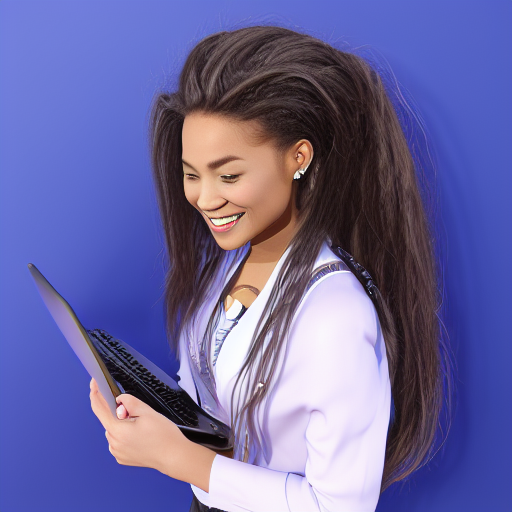

In [51]:
final_poster = draw_lora(f"poster illustration of {TRIGGER} holding a laptop, friendly smile, studio lighting, colorful background", seed=15, negative=bad)
final_poster.save(WORK / "images" / "poster_mascot.png")
final_poster

In [52]:
pipe = None; free_memory() 

In [53]:
import torch.nn as nn
from werkzeug.serving import make_server
from flask import Flask, jsonify, request
import threading

# ① 아주 작은 모델 학습: y = 2x + 1 을 스스로 알아내게 한다
tiny = nn.Linear(1, 1)
xs = torch.linspace(-3, 3, 50).unsqueeze(1); ys = 2 * xs + 1
opt = torch.optim.SGD(tiny.parameters(), lr=0.05)
for _ in range(300):
    loss = nn.functional.mse_loss(tiny(xs), ys); loss.backward(); opt.step(); opt.zero_grad()
torch.save(tiny.state_dict(), WORK / "models" / "tiny.pth")                # ② 학습 결과(숫자들)만 저장
print(f"학습된 모델: y = {tiny.weight.item():.2f}·x + {tiny.bias.item():.2f}")

# ③ 서버 쪽: 저장된 파일을 불러와 '추론 모드'로 대기
served = nn.Linear(1, 1); served.load_state_dict(torch.load(WORK / "models" / "tiny.pth")); served.eval()
mini = Flask("mini")

@mini.route("/predict", methods=["POST"])
def predict():
    value = float(request.json["value"])
    with torch.no_grad():
        out = served(torch.tensor([[value]])).item()
    return jsonify({"input": value, "prediction": round(out, 3)})            # ④ 결과를 JSON으로 응답

server = make_server("127.0.0.1", 5002, mini)
threading.Thread(target=server.serve_forever, daemon=True).start()          # 서버를 '뒤에서' 실행 (노트북은 계속 사용 가능)
time.sleep(1)

# ⑤ 클라이언트(손님) 쪽: 요청을 보낸다
for v in (0, 10, 2.5):
    print(f"요청 value={v}  →  응답:", requests.post("http://127.0.0.1:5002/predict", json={"value": v}).json())
server.shutdown()
print("🛑 미니 서버 종료")

학습된 모델: y = 2.00·x + 1.00


127.0.0.1 - - [07/Oct/2026 10:47:39] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [07/Oct/2026 10:47:39] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [07/Oct/2026 10:47:39] "POST /predict HTTP/1.1" 200 -


요청 value=0  →  응답: {'input': 0.0, 'prediction': 1.0}
요청 value=10  →  응답: {'input': 10.0, 'prediction': 21.0}
요청 value=2.5  →  응답: {'input': 2.5, 'prediction': 6.0}
🛑 미니 서버 종료


In [54]:
%%writefile moa_server.py
"""모아 AI 비서 서버 (Flask)  —  실행: python moa_server.py  →  http://localhost:5001"""
import base64, io, os, threading
from pathlib import Path
os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import chromadb, requests, torch
import torch.nn.functional as F
from chromadb.config import Settings
from flask import Flask, jsonify, request
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer

BASE = Path(__file__).resolve().parent
WORK = BASE / "work"
EMB_NAME = "intfloat/multilingual-e5-small"
SD_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"
OLLAMA_URL = os.environ.get("OLLAMA_URL", "http://localhost:11434")
LLM_MODEL = os.environ.get("LLM_MODEL", "gemma3:4b")
TRIGGER = "moa_character"
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

app = Flask(__name__)

# ─── 서버가 켜질 때 '한 번만' 모델을 불러 둔다 (요청마다 불러오면 너무 느리니까) ───
print("⏳ 모델 불러오는 중...", flush=True)
tok = AutoTokenizer.from_pretrained(EMB_NAME)
emb_model = AutoModel.from_pretrained(EMB_NAME).eval().to(DEVICE)                        # 귀 (임베딩)
sent_model = AutoModelForSequenceClassification.from_pretrained(WORK / "models" / "moa-sentiment").eval().to(DEVICE)   # 후기 감정 분류기
collection = chromadb.PersistentClient(path=str(WORK / "chroma"), settings=Settings(anonymized_telemetry=False)).get_collection("moa_knowledge")
_sd = {"pipe": None}                                                                      # 그림 모델은 첫 요청 때 불러온다(게으른 로딩)
_sd_lock = threading.Lock()                                                                # 그림은 한 번에 한 명씩

def embed(texts, prefix):
    enc = tok([prefix + t for t in texts], padding=True, truncation=True, max_length=512, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        h = emb_model(**enc).last_hidden_state
    m = enc["attention_mask"].unsqueeze(-1).float()
    return F.normalize((h * m).sum(1) / m.sum(1), p=2, dim=1).cpu().tolist()

def ask_llm(messages, temperature=0.1):
    r = requests.post(f"{OLLAMA_URL}/api/chat", json={"model": LLM_MODEL, "messages": messages, "stream": False,
                                                       "options": {"temperature": temperature}, "keep_alive": "30m"}, timeout=600)
    r.raise_for_status()
    return r.json()["message"]["content"]

RAG_SYSTEM = ("너는 대학 AI 입문 동아리 '모아'의 AI 비서 '모아'야. 반드시 아래 [참고 자료]에 있는 내용만 근거로 한국어 존댓말로 간결하게 대답해. "
              "자료에 답이 없으면 지어내지 말고 '제가 가진 자료에는 없는 내용이에요. 임원진에게 문의해 주세요.'라고 말해.")

# ─── 엔드포인트 (손님이 주문하는 창구들) ───
@app.get("/health")
def health():
    return jsonify({"status": "ok", "device": DEVICE, "chunks": collection.count()})

@app.post("/sentiment")
def sentiment():
    body = request.get_json(force=True)
    texts = body.get("texts") or [body.get("text", "")]
    enc = tok(texts, padding=True, truncation=True, max_length=64, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(sent_model(**enc).logits, dim=-1).cpu()
    labels = sent_model.config.id2label
    return jsonify([{"text": t, "label": labels[int(p.argmax())], "confidence": round(float(p.max()), 3)} for t, p in zip(texts, probs)])

@app.post("/ask")
def ask():
    question = request.get_json(force=True)["question"]
    res = collection.query(query_embeddings=embed([question], "query: "), n_results=3)
    sources = [m["source"] for m in res["metadatas"][0]]
    context = "\n\n".join(f"({s}) {d}" for s, d in zip(sources, res["documents"][0]))
    answer = ask_llm([{"role": "system", "content": RAG_SYSTEM},
                      {"role": "user", "content": f"[참고 자료]\n{context}\n\n[질문]\n{question}"}])
    return jsonify({"question": question, "answer": answer, "sources": sorted(set(sources))})

@app.post("/draw")
def draw():
    body = request.get_json(force=True)
    prompt, seed, steps = body["prompt"], int(body.get("seed", 0)), int(body.get("steps", 20))
    with _sd_lock:
        if _sd["pipe"] is None:
            from diffusers import DPMSolverMultistepScheduler, StableDiffusionPipeline
            dtype = torch.float16 if DEVICE != "cpu" else torch.float32
            p = StableDiffusionPipeline.from_pretrained(SD_ID, torch_dtype=dtype, variant="fp16", safety_checker=None,
                                                        requires_safety_checker=False).to(DEVICE)
            p.scheduler = DPMSolverMultistepScheduler.from_config(p.scheduler.config)
            p.set_progress_bar_config(disable=True)
            if (WORK / "models" / "moa-mascot-lora").exists():
                p.load_lora_weights(str(WORK / "models" / "moa-mascot-lora"))                  # 마스코트 LoRA 장착
            _sd["pipe"] = p
        image = _sd["pipe"](prompt, negative_prompt="low quality, blurry, deformed, watermark, text", num_inference_steps=steps,
                            generator=torch.Generator("cpu").manual_seed(seed)).images[0]
    buf = io.BytesIO(); image.save(buf, format="PNG")
    return jsonify({"prompt": prompt, "image_base64": base64.b64encode(buf.getvalue()).decode()})

PAGE = """<!doctype html><meta charset=utf-8><title>모아 AI 비서</title>
<body style="font-family:sans-serif;max-width:680px;margin:30px auto;padding:0 16px">
<h2>🤖 모아 AI 비서</h2>
<h3>💬 동아리에 대해 물어보세요</h3>
<input id=q style="width:75%;padding:8px" placeholder="예: 회비는 누구한테 내요?" onkeydown="if(event.key=='Enter')ask()">
<button onclick="ask()">질문</button><pre id=a style="white-space:pre-wrap;background:#f3f4f6;padding:10px"></pre>
<h3>😊 후기 감정 분석</h3>
<input id=r style="width:75%;padding:8px" placeholder="예: 간식도 맛있고 너무 즐거웠어요">
<button onclick="senti()">분석</button><pre id=s style="background:#f3f4f6;padding:10px"></pre>
<script>
async function post(u,b){return (await fetch(u,{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify(b)})).json()}
async function ask(){a.textContent='생각 중...';const d=await post('/ask',{question:q.value});a.textContent=d.answer+'\\n\\n📎 '+d.sources.join(', ')}
async function senti(){const d=await post('/sentiment',{text:r.value});s.textContent=d[0].label+' ('+Math.round(d[0].confidence*100)+'%)'}
</script></body>"""

@app.get("/")
def index():
    return PAGE

if __name__ == "__main__":
    app.run(host="127.0.0.1", port=int(os.environ.get("PORT", 5001)), threaded=True)

Writing moa_server.py


In [55]:
SERVER_URL = "http://127.0.0.1:5001"
_moa_proc = None

def moa_alive():
    try:
        return requests.get(f"{SERVER_URL}/health", timeout=2).ok
    except requests.RequestException:
        return False

def start_moa_server():
    global _moa_proc
    if moa_alive():
        print("이미 켜져 있어요 →", SERVER_URL); return
    log = open(WORK / "moa_server.log", "w")
    _moa_proc = subprocess.Popen([sys.executable, "moa_server.py"], cwd=BASE, stdout=log, stderr=log, start_new_session=True)
    for _ in range(180):                                       # 최대 90초 대기
        if moa_alive(): break
        if _moa_proc.poll() is not None:
            raise RuntimeError("서버가 바로 꺼졌어요. work/moa_server.log 를 확인하세요:\n" + (WORK / "moa_server.log").read_text()[-1500:])
        time.sleep(0.5)
    else:
        raise RuntimeError("서버 시작 시간 초과. work/moa_server.log 확인")
    print("🟢 모아 서버 가동!  →", SERVER_URL, "  (브라우저에서 열어 보세요)")

def stop_moa_server():
    global _moa_proc
    if _moa_proc and _moa_proc.poll() is None:
        _moa_proc.terminate(); _moa_proc.wait(timeout=15)
    _moa_proc = None
    print("🔴 모아 서버 종료")

start_moa_server()
print(requests.get(f"{SERVER_URL}/health").json())

🟢 모아 서버 가동!  → http://127.0.0.1:5001   (브라우저에서 열어 보세요)
{'chunks': 18, 'device': 'cuda', 'status': 'ok'}


In [56]:
reviews = ["해커톤 정말 재밌었어요! 또 하고 싶어요", "공지가 늦어서 준비를 못 했어요. 실망입니다", "간식이 맛있고 분위기가 좋았어요"]
print("😊 /sentiment")
for r in requests.post(f"{SERVER_URL}/sentiment", json={"texts": reviews}).json():
    print(f"   [{r['label']} {r['confidence']:.0%}] {r['text']}")

print("\n💬 /ask")
for q in ["해커톤 참가 신청은 언제까지예요?", "MT는 어디로 가고 참가비가 얼마예요?"]:
    d = requests.post(f"{SERVER_URL}/ask", json={"question": q}, timeout=300).json()
    print(f"   ❓ {q}\n   🤖 {d['answer']}\n   📎 {d['sources']}\n")

😊 /sentiment
   [긍정 88%] 해커톤 정말 재밌었어요! 또 하고 싶어요
   [부정 86%] 공지가 늦어서 준비를 못 했어요. 실망입니다
   [긍정 87%] 간식이 맛있고 분위기가 좋았어요

💬 /ask
   ❓ 해커톤 참가 신청은 언제까지예요?
   🤖 11월 7일 금요일까지 받습니다.
   📎 ['04_행사일정.txt', '05_자주묻는질문.txt']

   ❓ MT는 어디로 가고 참가비가 얼마예요?
   🤖 모아 MT는 5월 23일부터 24일까지 1박 2일로 가평에서 진행하며, MT 참가비는 40,000원입니다.
   📎 ['01_동아리소개.txt', '04_행사일정.txt']



⏱️ 196초


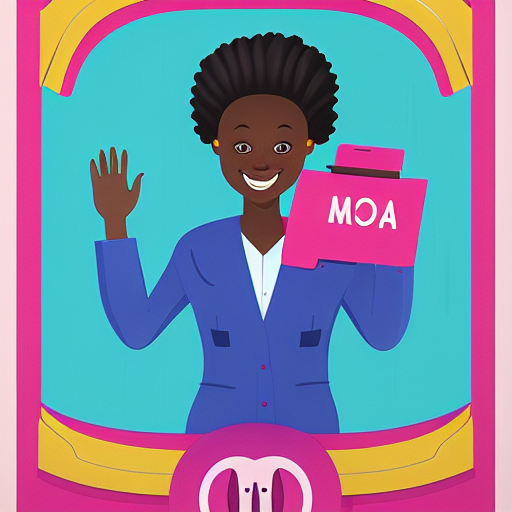

In [57]:
import base64, io
t0 = time.time()
d = requests.post(f"{SERVER_URL}/draw", json={"prompt": f"poster illustration of {TRIGGER} waving hello, friendly smile, colorful background", "seed": 5}, timeout=900).json()
server_img = Image.open(io.BytesIO(base64.b64decode(d["image_base64"])))
print(f"⏱️ {time.time() - t0:.0f}초")
server_img.save(WORK / "images" / "poster_from_server.png")
server_img

In [58]:
STOP_OLLAMA = False       # True로 바꾸면 이 노트북이 켠 Ollama 서버도 함께 종료

stop_moa_server()
requests.post(f"{OLLAMA_URL}/api/generate", json={"model": LLM_MODEL, "keep_alive": 0})     # 메모리에서 LLM 내리기
if STOP_OLLAMA and _ollama_proc is not None:
    _ollama_proc.terminate(); print("🔴 Ollama 서버 종료")
free_memory()
print("✅ 정리 완료")

🔴 모아 서버 종료
✅ 정리 완료
